In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv('TXF_R1_1min_data_combined.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

In [92]:
df_hourly = (
    df.set_index('datetime')
    .resample('1H')
    .agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    })
    .dropna()
    .reset_index()
)

/var/folders/6_/y6_9z6lj6qv9svn2kzt0rndr0000gn/T/ipykernel_96424/3484373210.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('1H')


In [93]:
import pandas as pd
import numpy as np

# 樣本內 / 樣本外期間
IN_SAMPLE_START = pd.Timestamp('2010-01-01')
IN_SAMPLE_END = pd.Timestamp('2019-12-31 23:59:59')
OOS_START =pd.Timestamp('2020-01-01')
OOS_END =pd.Timestamp('2025-06-30 23:59:59')

# 交易成本與合約設定
CONTRACT_TYPE = 'big'  # 'big'（大台）或 'mini'（小台）
COMMISSION_PER_SIDE = 200 if CONTRACT_TYPE == 'big' else 150  # TWD/口/單邊
POINT_VALUE = 200 if CONTRACT_TYPE == 'big' else 50           # TWD / 指數點

# 本金與滑價
INITIAL_CAPITAL = 1_000_000  # TWD
SLIPPAGE_POINTS = 0          # 以指數點為單位

# 依設定切出樣本內/外
def split_is_oos(df_hourly):
    df_is = df_hourly[
        (df_hourly['datetime'] >= IN_SAMPLE_START) &
        (df_hourly['datetime'] <= IN_SAMPLE_END)
    ].copy()

    df_oos = df_hourly[
        (df_hourly['datetime'] >= OOS_START) &
        (df_hourly['datetime'] <= OOS_END)
    ].copy()

    return df_is.reset_index(drop=True), df_oos.reset_index(drop=True)


print(f"CONTRACT_TYPE={CONTRACT_TYPE}, COMMISSION_PER_SIDE={COMMISSION_PER_SIDE} TWD, POINT_VALUE={POINT_VALUE} TWD/點")
# ↑ 印出目前使用的大/小台、單邊手續費、點值，方便檢查
print(f"IN-SAMPLE: {IN_SAMPLE_START} ~ {IN_SAMPLE_END}")          # 印出樣本內期間
print(f"OUT-OF-SAMPLE: {OOS_START} ~ {OOS_END}")                  # 印出樣本外期間
print(f"INITIAL_CAPITAL: {INITIAL_CAPITAL:,} TWD")                # 印出初始資金（含千分位）


CONTRACT_TYPE=big, COMMISSION_PER_SIDE=200 TWD, POINT_VALUE=200 TWD/點
IN-SAMPLE: 2010-01-01 00:00:00 ~ 2019-12-31 23:59:59
OUT-OF-SAMPLE: 2020-01-01 00:00:00 ~ 2025-06-30 23:59:59
INITIAL_CAPITAL: 1,000,000 TWD


In [94]:
def backtest_donchian_cash(df,
                           donchian_period,
                           exit_period,
                           initial_capital=INITIAL_CAPITAL,
                           commission_per_side=COMMISSION_PER_SIDE,
                           point_value=POINT_VALUE,
                           slippage_points=SLIPPAGE_POINTS):
    """
    Donchian 通道多空反向策略，固定 1 口，用「下一根開盤 ± 滑價」成交。
    回傳：
      - equity_df:資產曲線(datetime, equity)
      - trades:每筆交易(entry_time, exit_time, direction, 價格與損益）
      - metrics:績效指標(total_return, max_drawdown, sharpe, num_trades, win_rate)
    """

    # --- 防呆：資料太短直接回傳空結果 ---
    if df.empty or len(df) < max(donchian_period, exit_period) + 5:
        return {
            "equity_df": pd.DataFrame(),
            "trades": [],
            "metrics": {
                "total_return": np.nan,
                "max_drawdown": np.nan,
                "sharpe": np.nan,
                "num_trades": 0,
                "win_rate": np.nan
            }
        }

    df = df.copy()

    # --- 計算 Donchian 與 exit 通道（用前一根資料，避免未來資訊） ---
    df["upper"]      = df["High"].rolling(donchian_period).max().shift(1)
    df["lower"]      = df["Low"].rolling(donchian_period).min().shift(1)
    df["exit_upper"] = df["High"].rolling(exit_period).max().shift(1)
    df["exit_lower"] = df["Low"].rolling(exit_period).min().shift(1)

    cash        = float(initial_capital)
    position    = 0        # 0 無、+1 多、-1 空
    entry_price = None
    entry_time  = None

    trades      = []
    equity_times = []
    equity_vals  = []

    # --- 逐根 K 回測 ---
    for i in range(1, len(df)):
        prev = df.iloc[i-1]
        row  = df.iloc[i]

        # 若通道尚未形成（前幾根），只記錄資產不做交易
        if pd.isna(prev["upper"]) or pd.isna(prev["lower"]) \
           or pd.isna(prev["exit_upper"]) or pd.isna(prev["exit_lower"]):
            mtm_points = 0.0
            if position != 0 and entry_price is not None:
                mtm_points = (float(row["Close"]) - entry_price) * (1 if position == 1 else -1)
            equity = cash + mtm_points * point_value
            equity_times.append(row["datetime"])
            equity_vals.append(equity)
            continue

        # 成交價：下一根開盤 ± 滑價
        buy_open  = float(row["Open"]) + slippage_points   # 買進價（開盤偏高）
        sell_open = float(row["Open"]) - slippage_points   # 賣出價（開盤偏低）

        # --- 訊號：先決定「該不該平舊倉」 ---
        exit_long  = (position == 1  and prev["Close"] <= prev["exit_lower"])
        exit_short = (position == -1 and prev["Close"] >= prev["exit_upper"])

        # --- 訊號：再決定「是否產生新的多/空訊號」 ---
        long_signal  = (position <= 0 and prev["High"] > prev["upper"])
        short_signal = (position >= 0 and prev["Low"]  < prev["lower"])

        did_close = False

        # ========= 先處理平倉 =========
        if exit_long or exit_short:
            if position == 1:        # 平多：用賣價
                exit_price = sell_open
                direction  = "LONG"
                pnl_points = (exit_price - entry_price) * 1
            elif position == -1:     # 平空：用買價
                exit_price = buy_open
                direction  = "SHORT"
                pnl_points = (exit_price - entry_price) * -1
            else:
                exit_price = None
                direction  = None
                pnl_points = 0.0

            pnl_twd = pnl_points * point_value
            cash   += pnl_twd
            cash   -= commission_per_side

            trades.append({
                "entry_time": entry_time,
                "exit_time":  row["datetime"],
                "direction":  direction,
                "entry_price": entry_price,
                "exit_price":  exit_price,
                "pnl_points":  pnl_points,
                "pnl_twd":     pnl_twd
            })

            position    = 0
            entry_price = None
            entry_time  = None
            did_close   = True

        # ========= 再處理進場 / 反手 =========
        # 多頭訊號
        if long_signal:
            # 若原本是空單，但上面沒有因 exit 訊號平倉，這裡先平空再開多
            if position == -1 and not did_close and entry_price is not None:
                exit_price = buy_open      # 回補空單 → 用買價
                pnl_points = (exit_price - entry_price) * -1
                pnl_twd    = pnl_points * point_value
                cash      += pnl_twd
                cash      -= commission_per_side
                trades.append({
                    "entry_time": entry_time,
                    "exit_time": row["datetime"],
                    "direction": "SHORT",
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "pnl_points": pnl_points,
                    "pnl_twd": pnl_twd
                })

            # 開多
            if position <= 0:
                cash       -= commission_per_side
                entry_price = buy_open
                entry_time  = row["datetime"]
                position    = 1

        # 空頭訊號
        elif short_signal:
            # 若原本是多單，但上面沒有因 exit 訊號平倉，這裡先平多再開空
            if position == 1 and not did_close and entry_price is not None:
                exit_price = sell_open     # 賣出多單 → 用賣價
                pnl_points = (exit_price - entry_price) * 1
                pnl_twd    = pnl_points * point_value
                cash      += pnl_twd
                cash      -= commission_per_side
                trades.append({
                    "entry_time": entry_time,
                    "exit_time": row["datetime"],
                    "direction": "LONG",
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "pnl_points": pnl_points,
                    "pnl_twd": pnl_twd
                })

            # 開空
            if position >= 0:
                cash       -= commission_per_side
                entry_price = sell_open
                entry_time  = row["datetime"]
                position    = -1

        # --- 每根都記錄資產（現金 + 未實現損益） ---
        mtm_points = 0.0
        if position != 0 and entry_price is not None:
            mtm_points = (float(row["Close"]) - entry_price) * (1 if position == 1 else -1)

        equity = cash + mtm_points * point_value
        equity_times.append(row["datetime"])
        equity_vals.append(equity)

    # --- 產生資產曲線 DataFrame ---
    equity_df = pd.DataFrame({"datetime": equity_times, "equity": equity_vals})
    equity_df["ret"] = equity_df["equity"].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # --- 計算績效指標 ---
    if len(equity_df) > 1:
        cum_ret = equity_df["equity"].iloc[-1] / initial_capital - 1.0
        running_max = equity_df["equity"].cummax()
        dd = (equity_df["equity"] - running_max) / running_max
        max_dd = dd.min()
        ann_factor = np.sqrt(252 * 5)   # 小時線粗略換成年化
        sharpe = equity_df["ret"].mean() / (equity_df["ret"].std() + 1e-9) * ann_factor
    else:
        cum_ret, max_dd, sharpe = np.nan, np.nan, np.nan

    if trades:
        pnl_series = pd.Series([t["pnl_twd"] for t in trades])
        win_rate   = (pnl_series > 0).mean()
        num_trades = len(trades)
    else:
        win_rate, num_trades = np.nan, 0

    metrics = {
        "total_return": cum_ret,
        "max_drawdown": float(max_dd) if pd.notna(max_dd) else np.nan,
        "sharpe": sharpe,
        "num_trades": num_trades,
        "win_rate": win_rate
    }

    return {
        "equity_df": equity_df,
        "trades": trades,
        "metrics": metrics
    }


In [95]:
import os              #用來檢查檔案存不存在 (os.path.exists)
import math           #用來檢查檔案存不存在 (os.path.exists)
import pandas as pd    #之後做一些向上取整等運算。
import numpy as np     #處理表格（DataFrame）

def grid_search_with_checkpoint(df, donchian_list, exit_list, checkpoint_path="grid_is_results.parquet", save_every=200, metric="return"):  #網格搜尋 + 斷點續跑
    rows = []
    done = set()
    if os.path.exists(checkpoint_path):
        try:
            old = pd.read_parquet(checkpoint_path)
            if not old.empty:
                rows.extend(old.to_dict("records"))
                done = {(int(r["donchian"]), int(r["exit"])) for r in rows}
                print(f"[resume] 載入 {len(done)} 組已完成參數，將跳過重算。")
        except Exception as e:
            print(f"[warn] 讀取 checkpoint 失敗，將重算。原因：{e}")

    counter = 0
    for d in donchian_list:
        for e in exit_list:
            key = (int(d), int(e))
            if key in done:
                continue

            # 這裡改成呼叫你的 backtest 函式
            result = backtest_donchian_cash(df, d, e)
            m = result["metrics"]
            rows.append({
                "donchian": int(d),
                "exit": int(e),
                "sharpe": m["sharpe"],
                "return": m["total_return"],
                "max_drawdown": m["max_drawdown"]
            })
            counter += 1

            if counter % save_every == 0:
                pd.DataFrame(rows).to_parquet(checkpoint_path, index=False)
                print(f"[checkpoint] 已完成 {counter} 組，寫入 {checkpoint_path}")

    df_results = pd.DataFrame(rows)
    if not df_results.empty:
        df_results.to_parquet(checkpoint_path, index=False)
        print(f"[done] 共 {len(df_results)} 組結果，已寫入 {checkpoint_path}")
    return df_results


def pick_params_by_interval_stability(
    df_results: pd.DataFrame,
    window_d=10, window_e=10,
    metric="return",
    agg_on_e="qtop", q=0.2, good_quantile=0.8
):
    if df_results.empty:
        raise ValueError("df_results 為空，先跑 grid_search_with_checkpoint")

    def window_score(d, e):
        d_lo, d_hi = d - window_d//2, d + window_d//2
        e_lo, e_hi = e - window_e//2, e + window_e//2
        box = df_results[
            (df_results["donchian"].between(d_lo, d_hi)) &
            (df_results["exit"].between(e_lo, e_hi))
        ][metric]
        if box.empty:
            return -np.inf
        return box.mean()

    df_results = df_results.copy()
    df_results["stab_score"] = [
        window_score(int(r["donchian"]), int(r["exit"])) for _, r in df_results.iterrows()
    ]
    best_row = df_results.loc[df_results["stab_score"].idxmax()]
    best_d, best_e = int(best_row["donchian"]), int(best_row["exit"])

    def agg_dim(group, metric_col):
        vals = group[metric_col].dropna().values
        if len(vals) == 0:
            return np.nan
        if agg_on_e == "qtop":
            k = max(1, int(math.ceil(len(vals) * q)))
            topk = np.sort(vals)[-k:]
            return float(np.mean(topk))
        else:
            return float(np.mean(vals))

    d_table = (df_results.groupby("donchian")
               .apply(lambda g: agg_dim(g, metric))
               .reset_index(name=f"{metric}_agg"))

    e_table = (df_results.groupby("exit")
               .apply(lambda g: agg_dim(g, metric))
               .reset_index(name=f"{metric}_agg"))

    return (best_d, best_e), d_table, e_table


In [96]:
print

<function print>

In [97]:
df_is, df_oos = split_is_oos(df_hourly)

In [98]:
test = backtest_donchian_cash(df_is, 20, 50)
len(test["trades"]), test["metrics"]

(781,
 {'total_return': np.float64(0.36939999999999995),
  'max_drawdown': -0.3884883142715067,
  'sharpe': np.float64(0.18672298377423077),
  'num_trades': 781,
  'win_rate': np.float64(0.3854033290653009)})

In [99]:
df_is, df_oos = split_is_oos(df_hourly)

df_is_results = grid_search_with_checkpoint(
    df_is,
    donchian_list=range(1, 100),
    exit_list=range(1, 100),
    checkpoint_path="grid_is_results.parquet",
    save_every=200
)

(best_d, best_e), d_table, e_table = pick_params_by_interval_stability(
    df_is_results,
    window_d=10, window_e=10,
    agg_on_e="qtop", q=0.2, good_quantile=0.8
)

[resume] 載入 9801 組已完成參數，將跳過重算。
[done] 共 9801 組結果，已寫入 grid_is_results.parquet


/var/folders/6_/y6_9z6lj6qv9svn2kzt0rndr0000gn/T/ipykernel_96424/1624876423.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: agg_dim(g, metric))
/var/folders/6_/y6_9z6lj6qv9svn2kzt0rndr0000gn/T/ipykernel_96424/1624876423.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: agg_dim(g, metric))


In [100]:
print(f"樣本內(區間穩定)參數: donchian={best_d}, exit={best_e}")

# 4) 樣本外驗證
oos = backtest_donchian_cash(df_oos, best_d, best_e)
m = oos["metrics"]
print(
    f"OOS Sharpe={m['sharpe']:.3f}, "
    f"Return={m['total_return']:.2%}, "
    f"MDD={m['max_drawdown']:.2%}, "
    f"Trades={m['num_trades']}"
)

樣本內(區間穩定)參數: donchian=34, exit=1
OOS Sharpe=0.168, Return=34.20%, MDD=-44.57%, Trades=1540


In [101]:
def buy_and_hold_month_close(df,
                             initial_capital=INITIAL_CAPITAL,
                             commission_per_side=COMMISSION_PER_SIDE,
                             point_value=POINT_VALUE):

    df = df.copy()

    cash = float(initial_capital)
    position = 0
    entry_price = None
    entry_time = None

    trades = []
    equity_times = []
    equity_vals = []

    df["month"] = df["datetime"].dt.to_period("M")
    df["month_change"] = df["month"].ne(df["month"].shift(1))

    for i in range(1, len(df)):
        prev = df.iloc[i-1]
        row = df.iloc[i]

        # --- 原則：每月第一根開多、下個月第一根平倉 ---
        if prev["month_change"]:   # 月初 → 開多
            buy_price = float(row["Open"])
            cash -= commission_per_side
            entry_price = buy_price
            entry_time = row["datetime"]
            position = 1

        # 若進到新月份 → 平倉
        if row["month_change"] and position == 1 and entry_price is not None:
            sell_price = float(row["Open"])
            pnl_points = sell_price - entry_price
            pnl_twd = pnl_points * point_value
            cash += pnl_twd
            cash -= commission_per_side

            trades.append({
                "entry_time": entry_time,
                "exit_time": row["datetime"],
                "direction": "LONG",
                "entry_price": entry_price,
                "exit_price": sell_price,
                "pnl_points": pnl_points,
                "pnl_twd": pnl_twd
            })

            entry_price = None
            entry_time = None
            position = 0

        # --- 記錄資產 ---
        mtm = 0.0
        if position == 1 and entry_price is not None:
            mtm = (float(row["Close"]) - entry_price) * point_value

        equity = cash + mtm
        equity_times.append(row["datetime"])
        equity_vals.append(equity)

    # 建立 equity_df
    equity_df = pd.DataFrame({"datetime": equity_times, "equity": equity_vals})
    equity_df["ret"] = equity_df["equity"].pct_change().fillna(0)

    # 產生 metrics
    total_return = equity_df["equity"].iloc[-1] / initial_capital - 1
    running_max = equity_df["equity"].cummax()
    max_dd = ((equity_df["equity"] - running_max) / running_max).min()
    ann_factor = np.sqrt(252 * 24)
    sharpe = equity_df["ret"].mean() / (equity_df["ret"].std() + 1e-9) * ann_factor

    metrics = {
        "total_return": total_return,
        "max_drawdown": max_dd,
        "sharpe": sharpe,
        "num_trades": len(trades),
        "win_rate": np.nan
    }

    return {
        "equity_df": equity_df,
        "trades": trades,
        "metrics": metrics
    }


In [102]:
# 如果你有 best_d, best_e，就用那個
donchian_period = best_d   # 例如 20
exit_period     = best_e   # 例如 50
# 如果沒有，就直接寫死：
# donchian_period = 20
# exit_period     = 50

In [103]:
# In-Sample
don_is  = backtest_donchian_cash(df_is,  donchian_period, exit_period)
buyhold_is   = buy_and_hold_month_close(df_is)
# Out-of-Sample
don_oos = backtest_donchian_cash(df_oos, donchian_period, exit_period)
buyhold_oos  = buy_and_hold_month_close(df_oos)

# Full sample（全部 df_hourly）
don_full = backtest_donchian_cash(df_hourly, donchian_period, exit_period)
buyhold_full = buy_and_hold_month_close(df_hourly)

print("=== IS Donchian metrics ===")
print(don_is["metrics"])
print("\n=== IS Buy&Hold metrics ===")
print(buyhold_is["metrics"])

print("\n=== OOS Donchian metrics ===")
print(don_oos["metrics"])
print("\n=== OOS Buy&Hold metrics ===")
print(buyhold_oos["metrics"])

print("\n=== FULL Donchian metrics ===")
print(don_full["metrics"])
print("\n=== FULL Buy&Hold metrics ===")
print(buyhold_full["metrics"])

=== IS Donchian metrics ===
{'total_return': np.float64(1.2862), 'max_drawdown': -0.10159151193633953, 'sharpe': np.float64(0.6746436855641047), 'num_trades': 1369, 'win_rate': np.float64(0.4141709276844412)}

=== IS Buy&Hold metrics ===
{'total_return': np.float64(0.6739999999999999), 'max_drawdown': np.float64(-0.4395811877789221), 'sharpe': np.float64(0.5305369194505262), 'num_trades': 119, 'win_rate': nan}

=== OOS Donchian metrics ===
{'total_return': np.float64(0.3420000000000001), 'max_drawdown': -0.4457296119352946, 'sharpe': np.float64(0.16839048204629695), 'num_trades': 1540, 'win_rate': np.float64(0.39675324675324675)}

=== OOS Buy&Hold metrics ===
{'total_return': np.float64(1.9904000000000002), 'max_drawdown': np.float64(-0.7555384319013677), 'sharpe': np.float64(0.7242441590992301), 'num_trades': 65, 'win_rate': nan}

=== FULL Donchian metrics ===
{'total_return': np.float64(1.5588000000000002), 'max_drawdown': -0.2951984457396614, 'sharpe': np.float64(0.33433497893585956

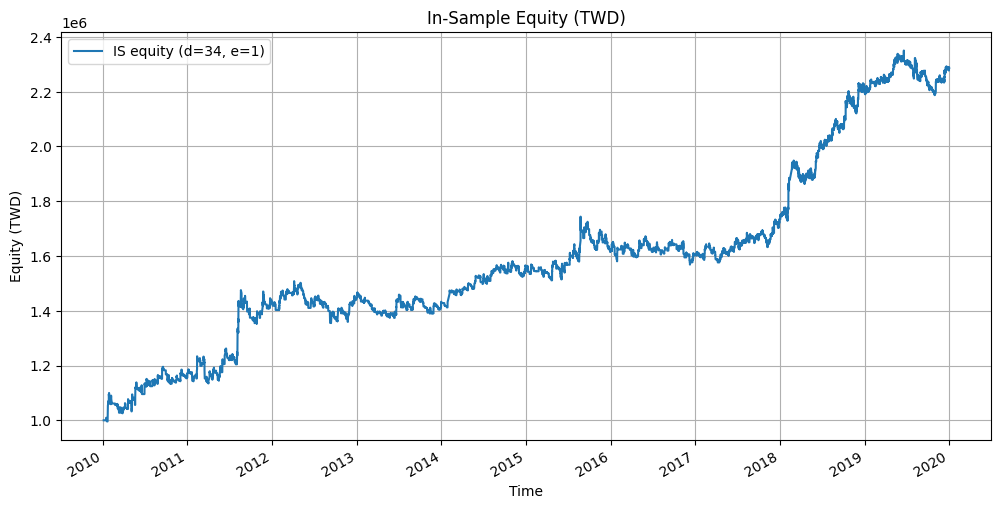

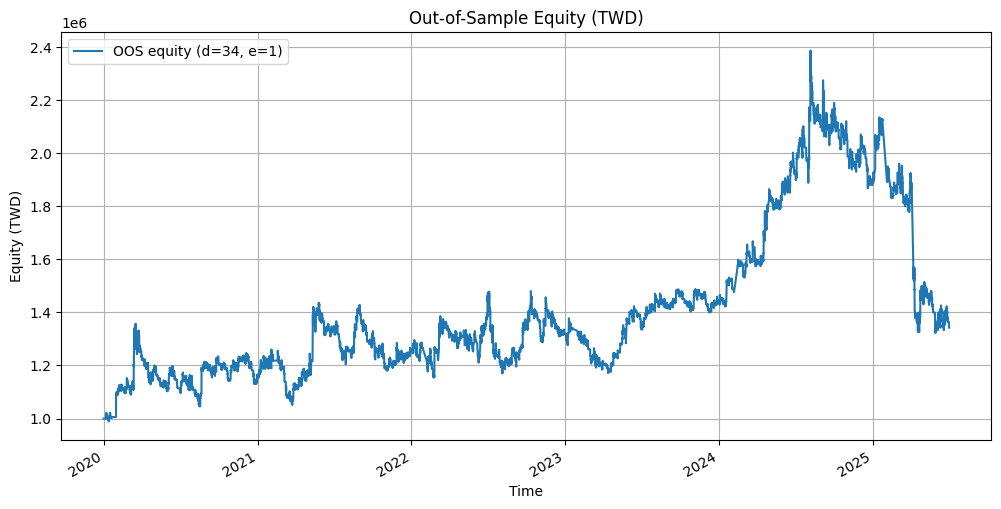

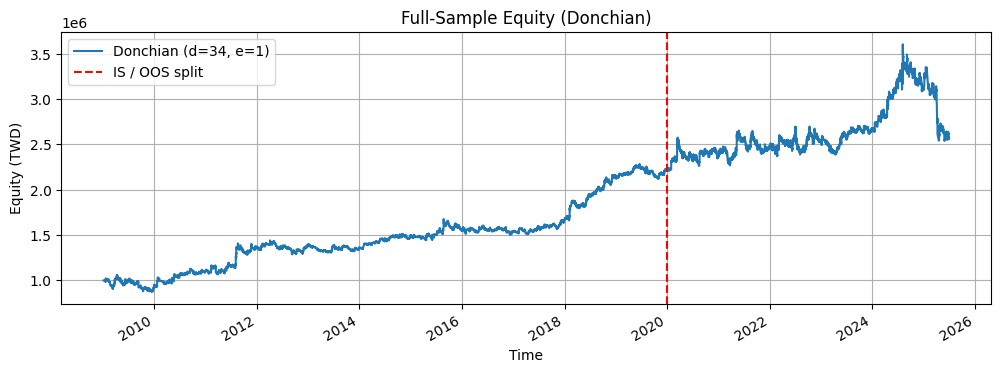

In [104]:
best = backtest_donchian_cash(df_is, best_d, best_e)  # 樣本內回測結果（含 equity_df）

# 繪製樣本內與樣本外的資產曲線（單位：TWD）
import matplotlib.pyplot as plt

# 🟢 使用你已經有的最佳參數（不是 best_key）
# 你前面已經有：(best_d, best_e), d_table, e_table = ...
# 所以這行不需要重新 assign 了，但保持明確性
best_d, best_e = best_d, best_e  

# 🟢 樣本內結果其實是 oos 的相同格式，只要你有用 best = backtest_donchian_cash(df_is, best_d, best_e)
# 如果你沒有 best，請先確保上面有跑：
# best = backtest_donchian_cash(df_is, best_d, best_e)

is_res = best      # 样本內
oos_res = oos      # 样本外（這是前面已經回測出來的變數）

# --- 樣本內 ---
plt.figure(figsize=(12,6))
plt.plot(
    is_res['equity_df']['datetime'],
    is_res['equity_df']['equity'],
    label=f'IS equity (d={best_d}, e={best_e})'
)
plt.title('In-Sample Equity (TWD)')
plt.xlabel('Time')
plt.ylabel('Equity (TWD)')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

# --- 樣本外 ---
plt.figure(figsize=(12,6))
plt.plot(
    oos_res['equity_df']['datetime'],
    oos_res['equity_df']['equity'],
    label=f'OOS equity (d={best_d}, e={best_e})'
)
plt.title('Out-of-Sample Equity (TWD)')
plt.xlabel('Time')
plt.ylabel('Equity (TWD)')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(don_full["equity_df"]["datetime"],
         don_full["equity_df"]["equity"],
         label=f"Donchian (d={donchian_period}, e={exit_period})")
plt.axvline(OOS_START, color="red", linestyle="--", label="IS / OOS split")
plt.title("Full-Sample Equity (Donchian)")
plt.xlabel("Time")
plt.ylabel("Equity (TWD)")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

In [105]:
# 先切樣本（你之前就有）
df_is, df_oos = split_is_oos(df_hourly)

# 這裡假設你已經選好 Donchian 參數
don_len = best_d   # 例如 40
exit_len = best_e  # 例如 110

# ============= 1) 樣本內回測 =============
is_don = backtest_donchian_cash(df_is, don_len, exit_len)
is_bh  = buy_and_hold_month_close(df_is)

eq_is_don = is_don["equity_df"]
eq_is_bh  = is_bh["equity_df"]

# ============= 2) 樣本外回測（用 IS 最後淨值當本金） =============
is_last_eq_don = eq_is_don["equity"].iloc[-1]
is_last_eq_bh  = eq_is_bh["equity"].iloc[-1]

oos_don = backtest_donchian_cash(
    df_oos, don_len, exit_len,
    initial_capital=is_last_eq_don   # ⭐ 關鍵：延續 IS 淨值
)
oos_bh = buy_and_hold_month_close(
    df_oos,
    initial_capital=is_last_eq_bh    # ⭐ Buy&Hold 也延續
)

eq_oos_don = oos_don["equity_df"]
eq_oos_bh  = oos_bh["equity_df"]

# ============= 3) 拼接成「模式 B 的 Full」 =============
full_don_eq = pd.concat([eq_is_don, eq_oos_don], ignore_index=True)
full_bh_eq  = pd.concat([eq_is_bh,  eq_oos_bh],  ignore_index=True)


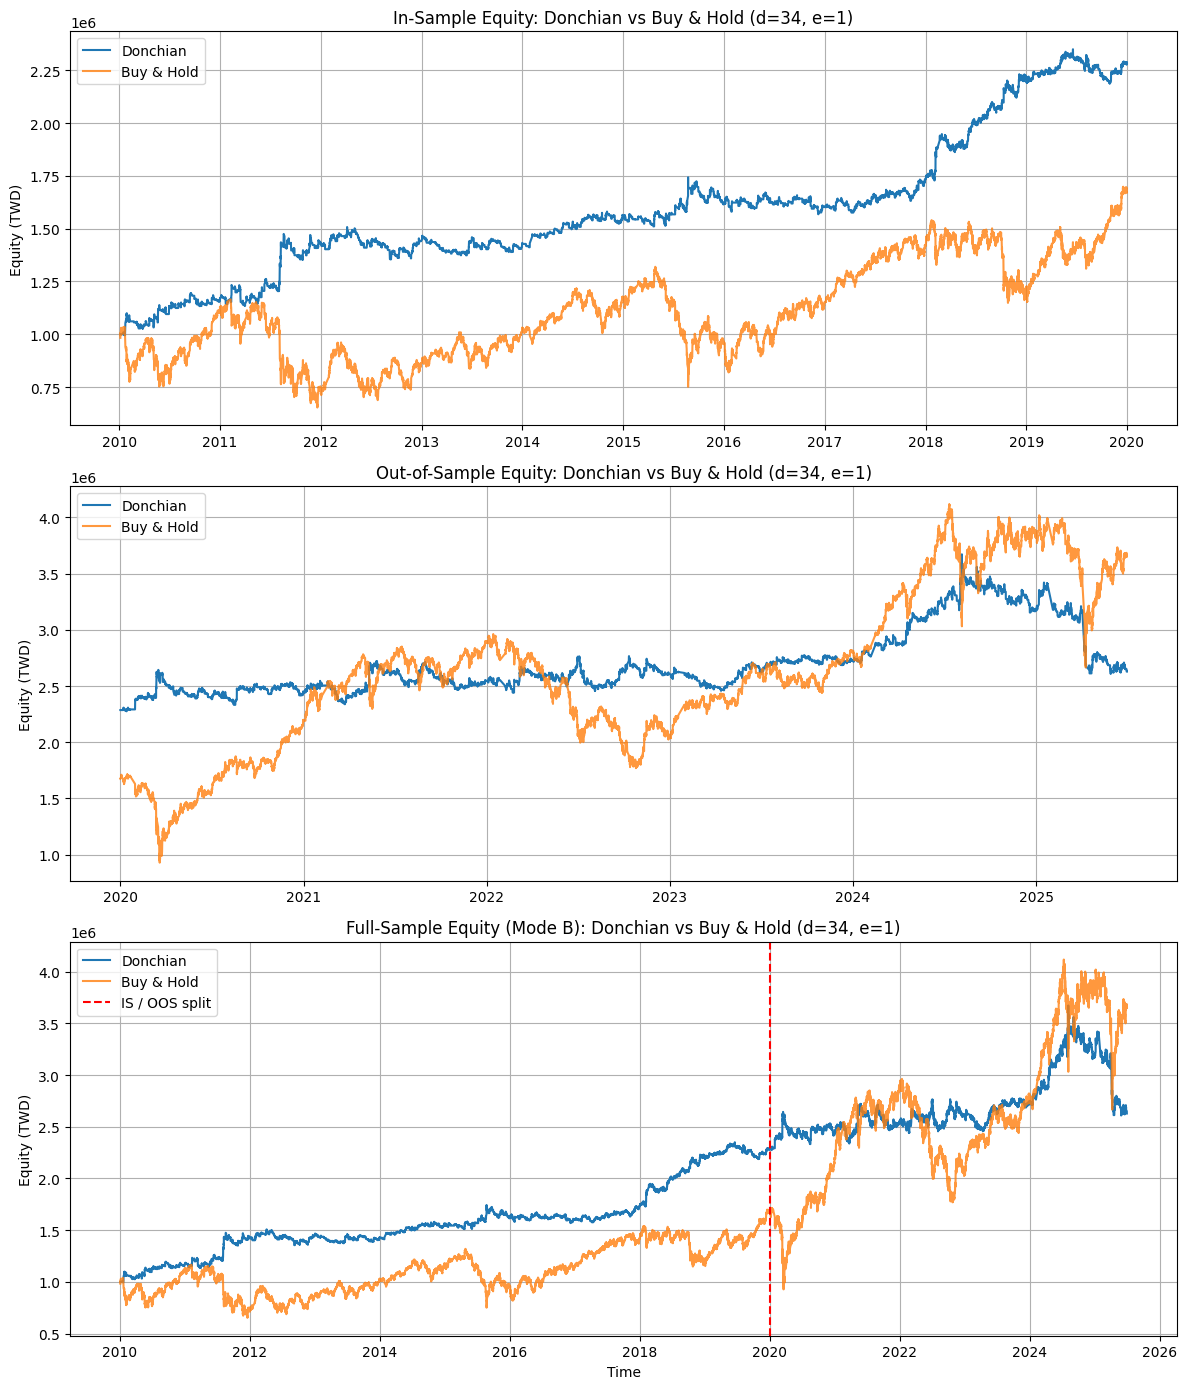

In [106]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=False)
ax1, ax2, ax3 = axes

# ---------- (1) In-Sample ----------
ax1.plot(eq_is_don["datetime"], eq_is_don["equity"], label="Donchian")
ax1.plot(eq_is_bh["datetime"],  eq_is_bh["equity"],  label="Buy & Hold", alpha=0.8)
ax1.set_title(f"In-Sample Equity: Donchian vs Buy & Hold (d={don_len}, e={exit_len})")
ax1.set_ylabel("Equity (TWD)")
ax1.legend()
ax1.grid(True)

# ---------- (2) Out-of-Sample ----------
ax2.plot(eq_oos_don["datetime"], eq_oos_don["equity"], label="Donchian")
ax2.plot(eq_oos_bh["datetime"],  eq_oos_bh["equity"],  label="Buy & Hold", alpha=0.8)
ax2.set_title(f"Out-of-Sample Equity: Donchian vs Buy & Hold (d={don_len}, e={exit_len})")
ax2.set_ylabel("Equity (TWD)")
ax2.legend()
ax2.grid(True)

# ---------- (3) Full Sample（模式 B：IS+OOS 拼接） ----------
ax3.plot(full_don_eq["datetime"], full_don_eq["equity"], label="Donchian")
ax3.plot(full_bh_eq["datetime"],  full_bh_eq["equity"],  label="Buy & Hold", alpha=0.8)

# 垂直線標 IS / OOS 切點
ax3.axvline(OOS_START, color="red", linestyle="--", label="IS / OOS split")

ax3.set_title(f"Full-Sample Equity (Mode B): Donchian vs Buy & Hold (d={don_len}, e={exit_len})")
ax3.set_xlabel("Time")
ax3.set_ylabel("Equity (TWD)")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()


In [107]:
print("best_d, best_e =", best_d, best_e)

print("OOS metrics:", m)

print("OOS trades count:", len(oos["trades"]))
print("OOS equity head:")
print(oos["equity_df"].head())

best_d, best_e = 34 1
OOS metrics: {'total_return': np.float64(0.3420000000000001), 'max_drawdown': -0.4457296119352946, 'sharpe': np.float64(0.16839048204629695), 'num_trades': 1540, 'win_rate': np.float64(0.39675324675324675)}
OOS trades count: 1540
OOS equity head:
             datetime     equity  ret
0 2020-01-01 01:00:00  1000000.0  0.0
1 2020-01-01 02:00:00  1000000.0  0.0
2 2020-01-01 03:00:00  1000000.0  0.0
3 2020-01-01 04:00:00  1000000.0  0.0
4 2020-01-01 05:00:00  1000000.0  0.0


In [108]:
print(best_d, best_e)

34 1


In [109]:
df_is_results.sort_values("return", ascending=False).head(10)

,donchian,exit,sharpe,return,max_drawdown
2872,30,2,0.657116,1.4006,-0.128522
2871,30,1,0.703928,1.3804,-0.097655
3664,38,2,0.668091,1.3778,-0.123614
2971,31,2,0.642632,1.3778,-0.128522
3070,32,2,0.646526,1.3724,-0.128522
3169,33,2,0.644743,1.3580,-0.124015
2773,29,2,0.644657,1.3554,-0.114888
2970,31,1,0.685214,1.3536,-0.098969
3168,33,1,0.698581,1.3460,-0.111050
2772,29,1,0.687697,1.3394,-0.088642


In [110]:
import os
os.path.exists("grid_is_results.parquet")

True

In [111]:
df_is_results = pd.read_parquet("grid_is_results.parquet")
df_is_results.head()

,donchian,exit,sharpe,return,max_drawdown
0,1,1,0.294271,-2.7850,-2.611062
1,1,2,-0.183792,-2.8332,-2.667500
2,1,3,-0.183813,-2.8260,-2.661068
3,1,4,-0.183806,-2.8284,-2.665178
4,1,5,0.284466,-2.8326,-2.674915


In [112]:
print(df_is.shape)
print(df_oos.shape)

(24435, 6)
(27974, 6)


In [113]:
test = backtest_donchian_cash(df_is, 20, 50)
test["metrics"], len(test["trades"])

({'total_return': np.float64(0.36939999999999995),
  'max_drawdown': -0.3884883142715067,
  'sharpe': np.float64(0.18672298377423077),
  'num_trades': 781,
  'win_rate': np.float64(0.3854033290653009)},
 781)

In [114]:
os.path.exists("grid_is_results.parquet")

True

In [115]:
df_is_results = pd.read_parquet("grid_is_results.parquet")
df_is_results.head()

,donchian,exit,sharpe,return,max_drawdown
0,1,1,0.294271,-2.7850,-2.611062
1,1,2,-0.183792,-2.8332,-2.667500
2,1,3,-0.183813,-2.8260,-2.661068
3,1,4,-0.183806,-2.8284,-2.665178
4,1,5,0.284466,-2.8326,-2.674915


In [116]:
df_is_results.sort_values("return", ascending=False).head(10)

df_is_results["return"].describe()
df_is_results["sharpe"].describe()

count    9801.000000
mean        0.137877
std         0.096920
min        -0.288716
25%         0.075310
50%         0.125880
75%         0.190972
max         0.703928
Name: sharpe, dtype: float64

In [117]:
# Donchian 統一命名
is_res_donchian   = is_res
oos_res_donchian  = oos_res
full_res_donchian = don_full

# Buy & Hold 統一命名
buyhold_is   = buyhold_is
buyhold_oos  = buyhold_oos
buyhold_full = buyhold_full

In [118]:
def performance_table(res, initial_capital=INITIAL_CAPITAL):
    equity = res["equity_df"]["equity"]
    trades = res["trades"]

    net_profit = equity.iloc[-1] - initial_capital
    gross_profit = sum(t["pnl_twd"] for t in trades if t["pnl_twd"] > 0)
    gross_loss   = sum(t["pnl_twd"] for t in trades if t["pnl_twd"] < 0)

    profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else np.nan
    avg_trade = net_profit / len(trades) if trades else np.nan
    max_loss_trade = min((t["pnl_twd"] for t in trades), default=np.nan)

    win_rate = np.mean([t["pnl_twd"] > 0 for t in trades]) if trades else np.nan

    # 最大連續虧損
    max_consec_loss = 0
    cur = 0
    for t in trades:
        if t["pnl_twd"] < 0:
            cur += t["pnl_twd"]
            max_consec_loss = min(max_consec_loss, cur)
        else:
            cur = 0

    m = res["metrics"]

    return {
        "Net Profit": net_profit,
        "Gross Profit": gross_profit,
        "Gross Loss": gross_loss,
        "Profit Factor": profit_factor,
        "Total Return": m["total_return"],
        "Sharpe": m["sharpe"],
        "Max Drawdown": m["max_drawdown"],
        "# Trades": m["num_trades"],
        "Win Rate": win_rate,
        "Avg Trade": avg_trade,
        "Max Loss Trade": max_loss_trade,
        "Max Consec Loss": max_consec_loss
    }

def compare_tables(is_d, is_bh, oos_d, oos_bh, full_d, full_bh):
    rows = []
    for name, res in [
        ("IS Donchian", is_d),
        ("IS Buy&Hold", is_bh),
        ("OOS Donchian", oos_d),
        ("OOS Buy&Hold", oos_bh),
        ("FULL Donchian", full_d),
        ("FULL Buy&Hold", full_bh),
    ]:
        r = performance_table(res)
        r["Sample"] = name
        rows.append(r)

    df_perf = pd.DataFrame(rows).set_index("Sample")
    return df_perf

df_perf = compare_tables(
    is_res_donchian, buyhold_is,
    oos_res_donchian, buyhold_oos,
    full_res_donchian, buyhold_full
)

df_perf

,Net Profit,Gross Profit,Gross Loss,Profit Factor,Total Return,Sharpe,Max Drawdown,# Trades,Win Rate,Avg Trade,Max Loss Trade,Max Consec Loss
Sample,,,,,,,,,,,,
IS Donchian,1286200.0,6393200.0,-4559400.0,1.402202,1.2862,0.674644,-0.101592,1369,0.414171,939.517896,-57800.0,-79600.0
IS Buy&Hold,674000.0,3502400.0,-2874800.0,1.218311,0.6740,0.530537,-0.439581,119,0.605042,5663.865546,-247600.0,-402800.0
OOS Donchian,342000.0,11628200.0,-10670200.0,1.089783,0.3420,0.168390,-0.445730,1540,0.396753,222.077922,-340600.0,-371200.0
OOS Buy&Hold,1990400.0,4960800.0,-3167400.0,1.566206,1.9904,0.724244,-0.755538,65,0.615385,30621.538462,-406400.0,-507800.0
FULL Donchian,1558800.0,18569000.0,-15807400.0,1.174703,1.5588,0.334335,-0.295198,3007,0.405055,518.390422,-340600.0,-371200.0
FULL Buy&Hold,3365200.0,9609600.0,-6388600.0,1.504179,3.3652,0.803042,-0.325672,197,0.614213,17082.233503,-406400.0,-507800.0


In [119]:
print(equity_df["datetime"].min(), equity_df["datetime"].max())
print(equity_df.head(3)[["datetime","equity"]])

2009-01-05 09:00:00 2025-06-30 23:00:00
             datetime     equity
0 2009-01-05 09:00:00  1000000.0
1 2009-01-05 10:00:00  1000000.0
2 2009-01-05 11:00:00  1000000.0


In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_equity_and_drawdown(res, title_prefix="Donchian Strategy",
                             start_date=None, end_date=None):
    """
    畫出：
    1) Equity curve + entry points
    2) Max drawdown (points)
    全英文標示
    """

    # -----------------------
    # 取 equity_df
    # -----------------------
    equity_df = res["equity_df"].copy()

    # 強制正確 datetime
    equity_df["datetime"] = pd.to_datetime(equity_df["datetime"], errors="coerce")
    equity_df = equity_df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    # 如果有指定樣本期間
    if start_date is not None:
        equity_df = equity_df[equity_df["datetime"] >= pd.to_datetime(start_date)]
    if end_date is not None:
        equity_df = equity_df[equity_df["datetime"] <= pd.to_datetime(end_date)]

    if equity_df.empty:
        print("❌ equity_df is empty. Check your date range.")
        return

    # -----------------------
    # 計算最大回撤
    # -----------------------
    equity = equity_df["equity"].values
    running_max = np.maximum.accumulate(equity)
    dd_points = equity - running_max
    dd_pct = dd_points / running_max

    equity_df["dd_points"] = dd_points
    equity_df["dd_pct"] = dd_pct

    # -----------------------
    # 取進場點（綠點）
    # -----------------------
    trades = res.get("trades", [])
    entry_times = pd.to_datetime(
        [t["entry_time"] for t in trades if t.get("entry_time") is not None],
        errors="coerce"
    )
    entry_times = entry_times.dropna()

    if len(entry_times) > 0:
        entry_df = pd.DataFrame({"datetime": entry_times})
        entry_df = entry_df.sort_values("datetime")

        # 用 asof 找最接近的 equity 值
        entry_df = pd.merge_asof(entry_df, 
                                 equity_df[["datetime", "equity"]],
                                 on="datetime",
                                 direction="nearest")
    else:
        entry_df = pd.DataFrame({"datetime": [], "equity": []})

    # -----------------------
    # 開始畫圖
    # -----------------------
    fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                             sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})

    # ======== 上圖：Equity ========
    axes[0].plot(equity_df["datetime"], equity_df["equity"],
                 label="Equity Curve", color="steelblue")

    axes[0].scatter(entry_df["datetime"], entry_df["equity"],
                    s=18, color="limegreen", label="Entry", zorder=5)

    axes[0].set_title(f"{title_prefix} - Trading Equity Curve")
    axes[0].set_ylabel("Equity (TWD)")
    axes[0].grid(True)
    axes[0].legend()

    # ======== 下圖：Drawdown ========
    axes[1].bar(equity_df["datetime"], equity_df["dd_points"],
                color="red", label="Drawdown (points)")

    axes[1].set_title("Maximum Drawdown (Points)")
    axes[1].set_ylabel("Drawdown (points)")
    axes[1].grid(True)

    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()


In [121]:
res = backtest_donchian_cash(df_hourly, 34, 1)
equity_df = res["equity_df"]
equity_df.head()
equity_df.tail()
equity_df.dtypes

datetime    datetime64[ns]
equity             float64
ret                float64
dtype: object

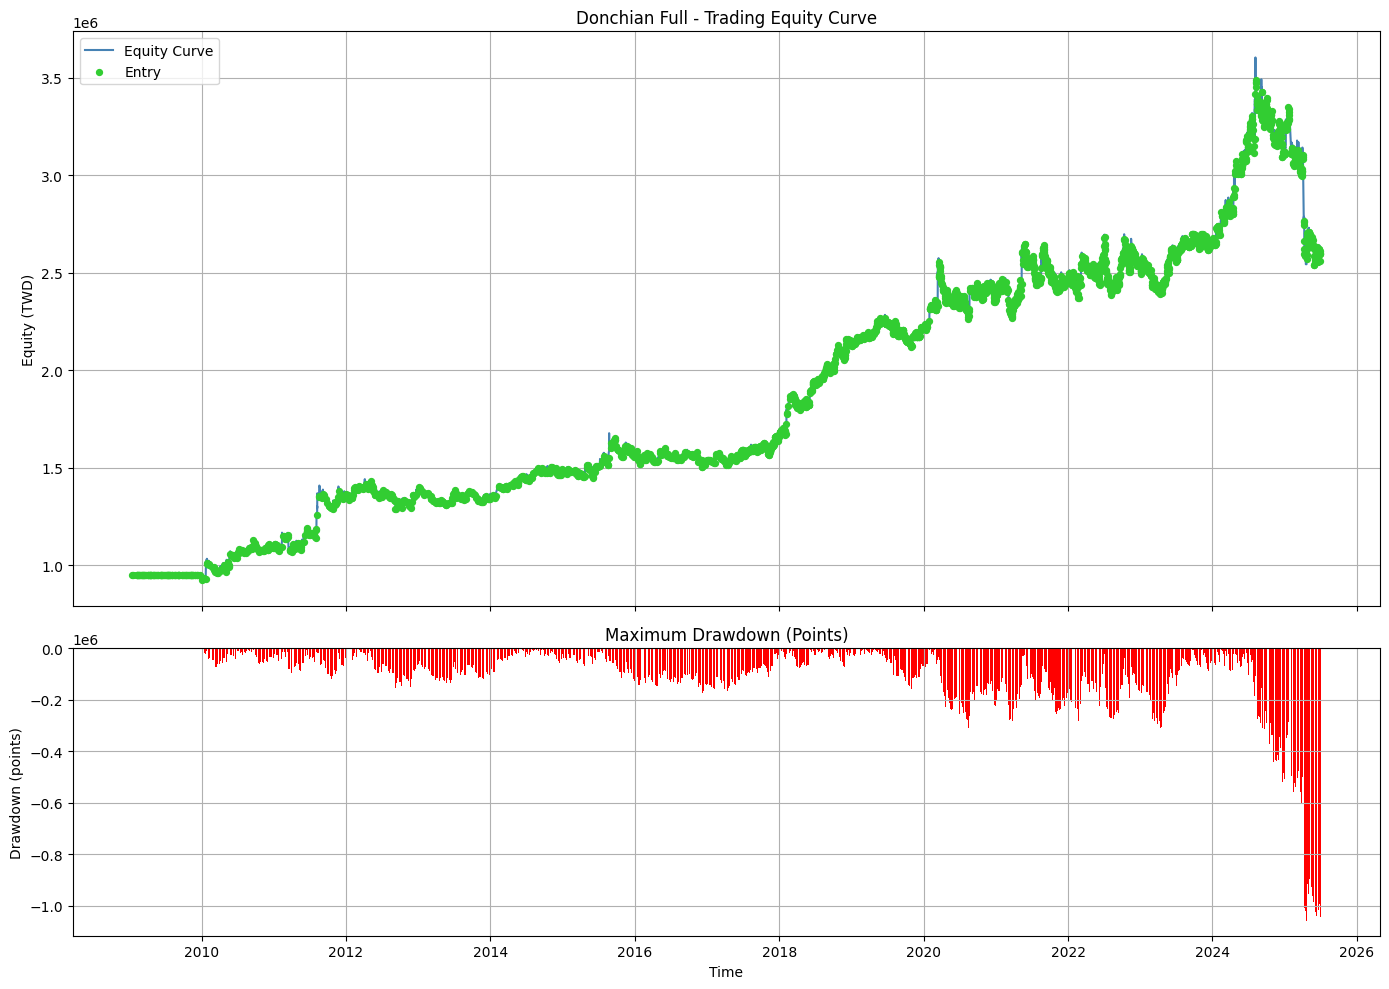

In [122]:
plot_equity_and_drawdown(full_res_donchian,
                         title_prefix="Donchian Full",
                         start_date=IN_SAMPLE_START)

Running Donchian...
Running Buy & Hold (monthly roll)...


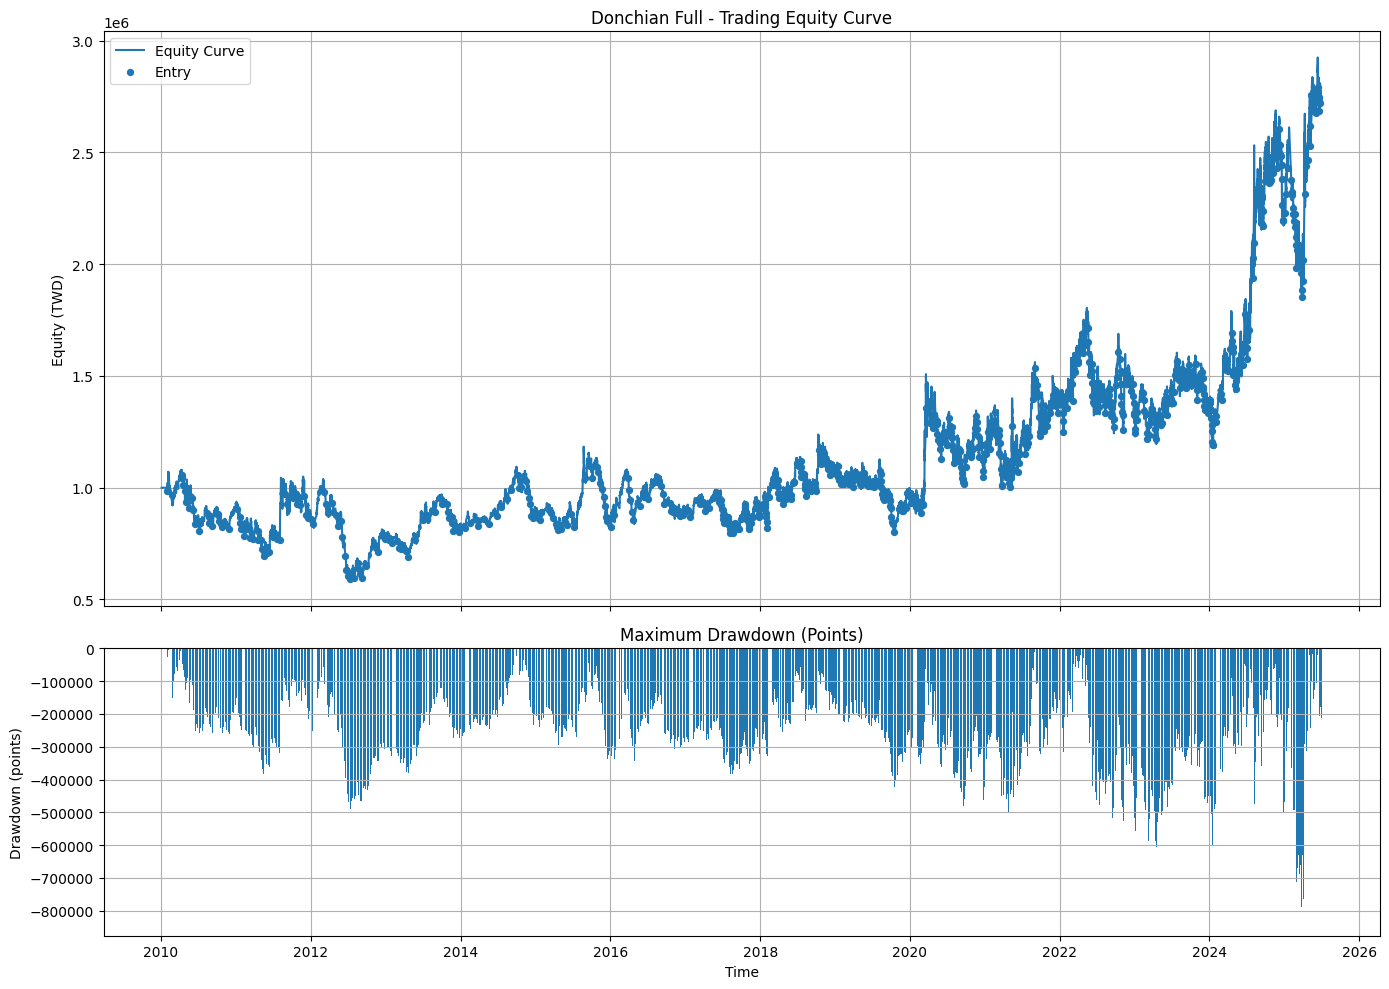

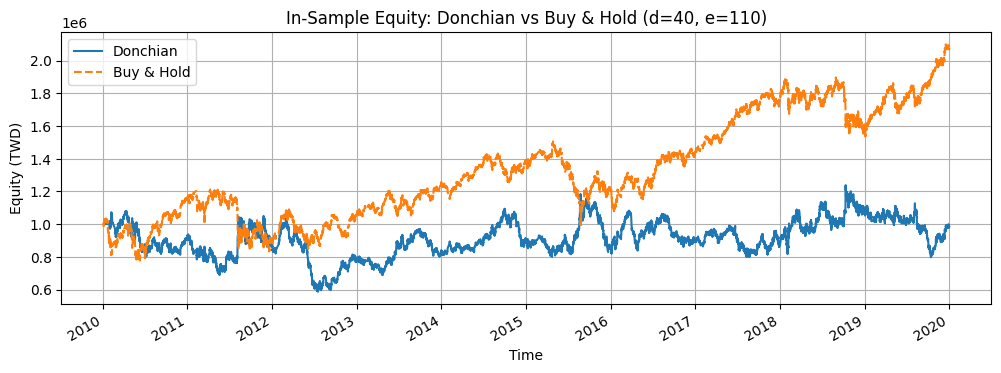

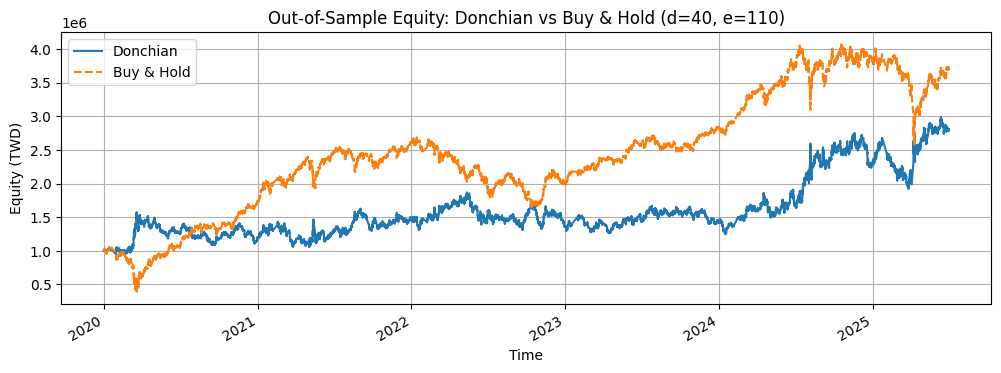

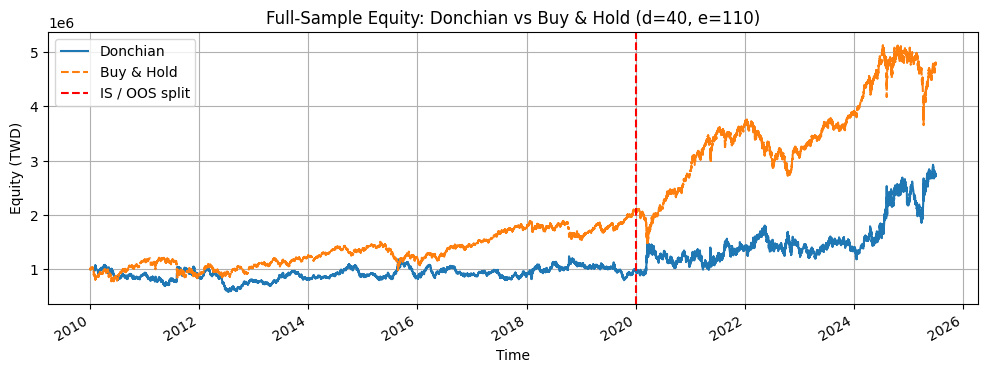

,Net Profit,Gross Profit,Gross Loss,Profit Factor,Total Return,Sharpe,Max Drawdown,# Trades,Win Rate,Avg Trade,Max Loss Trade,Max Consec Loss
Sample,,,,,,,,,,,,
IS Donchian,467000.0,5497400.0,-5030400.0,1.092836,-0.0162,0.093806,-0.456598,406,0.376847,1150.246305,-78600.0,-250200.0
IS Buy&Hold,1232800.0,3693600.0,-2460800.0,1.500975,1.0728,0.331393,-0.348612,116,0.568966,10627.586207,-175800.0,-306800.0
OOS Donchian,2348200.0,11888800.0,-9540600.0,1.246127,1.7980,0.331689,-0.333405,447,0.371365,5253.243848,-124200.0,-328800.0
OOS Buy&Hold,2738200.0,6381400.0,-3643200.0,1.751592,2.7126,0.421617,-0.625455,66,0.636364,41487.878788,-479400.0,-745000.0
FULL Donchian,2774200.0,17390800.0,-14616600.0,1.189798,1.7332,0.220203,-0.456598,856,0.373832,3240.887850,-124200.0,-328800.0
FULL Buy&Hold,3951000.0,10055000.0,-6104000.0,1.647280,3.7862,0.368027,-0.348612,182,0.593407,21708.791209,-479400.0,-745000.0


In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0. 基本參數（自己可改）
# =========================
INITIAL_CAPITAL      = 1_000_000
COMMISSION_PER_SIDE  = 600          # 大台單邊 600；小台改 150
POINT_VALUE          = 200          # 大台 1 點 = 200；小台改 50
SLIPPAGE_POINTS      = 0            # 你先設 0 或 1 都可

IN_SAMPLE_START = "2010-01-01"
IN_SAMPLE_END   = "2019-12-31 23:59:59"
OOS_START       = "2020-01-01"
OOS_END         = "2025-06-30 23:59:59"


# =========================
# 1. 切 IS / OOS
# =========================
def split_is_oos(df):
    df_is = df[(df["datetime"] >= IN_SAMPLE_START) &
               (df["datetime"] <= IN_SAMPLE_END)].copy()
    df_oos = df[(df["datetime"] >= OOS_START) &
                (df["datetime"] <= OOS_END)].copy()
    return df_is.reset_index(drop=True), df_oos.reset_index(drop=True)


# =========================
# 2. Donchian 回測（你原本的版本）
# =========================
def backtest_donchian_cash(df,
                           donchian_period,
                           exit_period,
                           initial_capital=INITIAL_CAPITAL,
                           commission_per_side=COMMISSION_PER_SIDE,
                           point_value=POINT_VALUE,
                           slippage_points=SLIPPAGE_POINTS):
    """
    Donchian 通道多空反向策略，固定 1 口，用「下一根開盤 ± 滑價」成交。
    回傳：
      - equity_df:資產曲線(datetime, equity, ret)
      - trades:每筆交易(entry_time, exit_time, direction, 價格與損益）
      - metrics:績效指標
    """

    # 防呆
    if df.empty or len(df) < max(donchian_period, exit_period) + 5:
        return {
            "equity_df": pd.DataFrame(),
            "trades": [],
            "metrics": {
                "total_return": np.nan,
                "max_drawdown": np.nan,
                "sharpe": np.nan,
                "num_trades": 0,
                "win_rate": np.nan
            }
        }

    df = df.copy()

    # Donchian 與 exit 通道（shift(1) 避免未來資訊）
    df["upper"]      = df["High"].rolling(donchian_period).max().shift(1)
    df["lower"]      = df["Low"].rolling(donchian_period).min().shift(1)
    df["exit_upper"] = df["High"].rolling(exit_period).max().shift(1)
    df["exit_lower"] = df["Low"].rolling(exit_period).min().shift(1)

    cash        = float(initial_capital)
    position    = 0        # 0 無、+1 多、-1 空
    entry_price = None
    entry_time  = None

    trades       = []
    equity_times = []
    equity_vals  = []

    for i in range(1, len(df)):
        prev = df.iloc[i-1]
        row  = df.iloc[i]

        # 通道尚未形成
        if pd.isna(prev["upper"]) or pd.isna(prev["lower"]) \
           or pd.isna(prev["exit_upper"]) or pd.isna(prev["exit_lower"]):
            mtm_points = 0.0
            if position != 0 and entry_price is not None:
                mtm_points = (float(row["Close"]) - entry_price) * (1 if position == 1 else -1)
            equity = cash + mtm_points * point_value
            equity_times.append(row["datetime"])
            equity_vals.append(equity)
            continue

        # 下一根開盤成交 + 滑價
        buy_open  = float(row["Open"]) + slippage_points
        sell_open = float(row["Open"]) - slippage_points

        # 平倉訊號
        exit_long  = (position == 1  and prev["Close"] <= prev["exit_lower"])
        exit_short = (position == -1 and prev["Close"] >= prev["exit_upper"])

        # 進場訊號
        long_signal  = (position <= 0 and prev["High"] > prev["upper"])
        short_signal = (position >= 0 and prev["Low"]  < prev["lower"])

        did_close = False

        # ===== 先平倉 =====
        if exit_long or exit_short:
            if position == 1:
                exit_price = sell_open
                direction  = "LONG"
                pnl_points = (exit_price - entry_price)
            elif position == -1:
                exit_price = buy_open
                direction  = "SHORT"
                pnl_points = (exit_price - entry_price) * -1

            pnl_twd = pnl_points * point_value
            cash   += pnl_twd
            cash   -= commission_per_side

            trades.append({
                "entry_time": entry_time,
                "exit_time":  row["datetime"],
                "direction":  direction,
                "entry_price": entry_price,
                "exit_price":  exit_price,
                "pnl_points":  pnl_points,
                "pnl_twd":     pnl_twd
            })

            position    = 0
            entry_price = None
            entry_time  = None
            did_close   = True

        # ===== 再進場 / 反手 =====
        if long_signal:
            # 反手：若原本是空單
            if position == -1 and not did_close and entry_price is not None:
                exit_price = buy_open
                pnl_points = (exit_price - entry_price) * -1
                pnl_twd    = pnl_points * point_value
                cash      += pnl_twd
                cash      -= commission_per_side
                trades.append({
                    "entry_time": entry_time,
                    "exit_time": row["datetime"],
                    "direction": "SHORT",
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "pnl_points": pnl_points,
                    "pnl_twd": pnl_twd
                })

            if position <= 0:
                cash       -= commission_per_side
                entry_price = buy_open
                entry_time  = row["datetime"]
                position    = 1

        elif short_signal:
            # 反手：若原本是多單
            if position == 1 and not did_close and entry_price is not None:
                exit_price = sell_open
                pnl_points = (exit_price - entry_price)
                pnl_twd    = pnl_points * point_value
                cash      += pnl_twd
                cash      -= commission_per_side
                trades.append({
                    "entry_time": entry_time,
                    "exit_time": row["datetime"],
                    "direction": "LONG",
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "pnl_points": pnl_points,
                    "pnl_twd": pnl_twd
                })

            if position >= 0:
                cash       -= commission_per_side
                entry_price = sell_open
                entry_time  = row["datetime"]
                position    = -1

        # ===== 記錄資產 =====
        mtm_points = 0.0
        if position != 0 and entry_price is not None:
            mtm_points = (float(row["Close"]) - entry_price) * (1 if position == 1 else -1)

        equity = cash + mtm_points * point_value
        equity_times.append(row["datetime"])
        equity_vals.append(equity)

    equity_df = pd.DataFrame({"datetime": equity_times, "equity": equity_vals})
    equity_df["ret"] = equity_df["equity"].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # 績效
    if len(equity_df) > 1:
        cum_ret = equity_df["equity"].iloc[-1] / initial_capital - 1.0
        running_max = equity_df["equity"].cummax()
        dd = (equity_df["equity"] - running_max) / running_max
        max_dd = dd.min()
        ann_factor = np.sqrt(252 * 5)   # 1H 粗略年化
        sharpe = equity_df["ret"].mean() / (equity_df["ret"].std() + 1e-9) * ann_factor
    else:
        cum_ret, max_dd, sharpe = np.nan, np.nan, np.nan

    if trades:
        pnl_series = pd.Series([t["pnl_twd"] for t in trades])
        win_rate   = (pnl_series > 0).mean()
        num_trades = len(trades)
    else:
        win_rate, num_trades = np.nan, 0

    metrics = {
        "total_return": cum_ret,
        "max_drawdown": float(max_dd) if pd.notna(max_dd) else np.nan,
        "sharpe": sharpe,
        "num_trades": num_trades,
        "win_rate": win_rate
    }

    return {"equity_df": equity_df, "trades": trades, "metrics": metrics}

# 生成「每月第三個星期三」的日期集合
# ======================================================
def get_third_wednesdays(start_date, end_date):
    """
    回傳期間內每個月第 3 個星期三 (date 格式)
    """
    all_weds = pd.date_range(start=start_date, end=end_date, freq="W-WED")
    s = all_weds.to_series()
    third_weds = (
        s.groupby([s.dt.year, s.dt.month])
         .nth(2)                # 每月第 3 個星期三（index=0 的第 3 個 → nth(2)）
         .dt.normalize()
    )
    return set(third_weds)

# =========================
# 3. Buy & Hold（每月結倉+續抱）
# =========================
def backtest_buyhold_monthly_roll(df,
                                  initial_capital=INITIAL_CAPITAL,
                                  commission_per_side=COMMISSION_PER_SIDE,
                                  point_value=POINT_VALUE,
                                  slippage_points=SLIPPAGE_POINTS):
    """
    Buy & Hold，但每個月『第三個星期三』強制結倉，
    並且「隔一天」才重新建新倉。
    """

    if df.empty:
        return {"equity_df": pd.DataFrame(), "trades": [], "metrics": {}}

    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

    # 建立每月第 3 個星期三清單（用你前面定義的 get_third_wednesdays）
    start_date = df["datetime"].min().normalize()
    end_date   = df["datetime"].max().normalize()
    expiry_dates = get_third_wednesdays(start_date, end_date)

    cash        = float(initial_capital)
    position    = 0          # 0: 無倉, 1: 多單
    entry_price = None
    entry_time  = None

    trades = []
    equity_times, equity_vals = [], []

    for i in range(1, len(df)):
        prev = df.iloc[i-1]
        row  = df.iloc[i]

        buy_open  = float(row["Open"]) + slippage_points
        sell_open = float(row["Open"]) - slippage_points
        today     = row["datetime"].normalize()  # 只保留日期（yyyy-mm-dd）

        # ===========================
        # 1. 若今天是「第 3 星期三」→ 只負責平倉，不開新倉
        # ===========================
        if position == 1 and today in expiry_dates:
            # 強制平倉
            exit_price = sell_open
            pnl_points = exit_price - entry_price
            pnl_twd    = pnl_points * point_value
            cash      += pnl_twd
            cash      -= commission_per_side

            trades.append({
                "entry_time": entry_time,
                "exit_time": row["datetime"],
                "direction": "LONG",
                "entry_price": entry_price,
                "exit_price": exit_price,
                "pnl_points": pnl_points,
                "pnl_twd": pnl_twd
            })

            position    = 0
            entry_price = None
            entry_time  = None
            # ⚠️ 當天就到這裡為止，不再開新倉（等明天再說）

        # ===========================
        # 2. 其它日：若目前沒倉 → 建立多單
        # ===========================
        if position == 0 and today not in expiry_dates:
            # 正常日，沒有部位 → 開一口多單
            cash       -= commission_per_side
            entry_price = buy_open
            entry_time  = row["datetime"]
            position    = 1

        # ===========================
        # 3. 記錄淨值（不管有沒有動作，每根都記）
        # ===========================
        mtm_points = 0.0
        if position == 1 and entry_price is not None:
            mtm_points = float(row["Close"]) - entry_price

        equity = cash + mtm_points * point_value
        equity_times.append(row["datetime"])
        equity_vals.append(equity)

    # ========== 產生 equity_df ==========
    equity_df = pd.DataFrame({"datetime": equity_times, "equity": equity_vals})
    equity_df["ret"] = (
        equity_df["equity"].pct_change()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    # ========== 計算績效 ==========
    running_max = equity_df["equity"].cummax()
    dd = (equity_df["equity"] - running_max) / running_max
    ann_factor = np.sqrt(252 * 5)

    metrics = {
        "total_return": equity_df["equity"].iloc[-1] / initial_capital - 1.0,
        "max_drawdown": float(dd.min()),
        "sharpe": equity_df["ret"].mean() / (equity_df["ret"].std() + 1e-9) * ann_factor,
        "num_trades": len(trades),
        "win_rate": np.nan
    }

    return {"equity_df": equity_df, "trades": trades, "metrics": metrics}

# =========================
# 4. 用學長格式做績效表
# =========================
def performance_row(res, sample_name):
    trades = res["trades"]
    equity_df = res["equity_df"]
    m = res["metrics"]

    if trades:
        pnl = pd.Series([t["pnl_twd"] for t in trades])
        gross_profit = pnl[pnl > 0].sum()
        gross_loss   = pnl[pnl < 0].sum()
        net_profit   = pnl.sum()
        profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else np.nan
        avg_trade = pnl.mean()
        max_loss_trade = pnl.min()

        # 最大連續虧損（TWD）
        consec = []
        s = 0
        for x in pnl:
            if x < 0:
                s += x
            else:
                consec.append(s)
                s = 0
        consec.append(s)
        max_consec_loss = min(consec) if consec else 0
        win_rate = (pnl > 0).mean()
        num_trades = len(pnl)
    else:
        gross_profit = gross_loss = net_profit = avg_trade = max_loss_trade = max_consec_loss = np.nan
        profit_factor = win_rate = np.nan
        num_trades = 0

    return {
        "Sample": sample_name,
        "Net Profit": net_profit,
        "Gross Profit": gross_profit,
        "Gross Loss": gross_loss,
        "Profit Factor": profit_factor,
        "Total Return": m.get("total_return", np.nan),
        "Sharpe": m.get("sharpe", np.nan),
        "Max Drawdown": m.get("max_drawdown", np.nan),
        "# Trades": num_trades,
        "Win Rate": win_rate,
        "Avg Trade": avg_trade,
        "Max Loss Trade": max_loss_trade,
        "Max Consec Loss": max_consec_loss
    }


# =========================
# 5. 圖：Donchian 淨值+綠點 / 回撤柱狀
# =========================
def plot_equity_and_drawdown(res, title_prefix="Donchian Strategy"):
    equity_df = res["equity_df"].copy()
    equity_df["datetime"] = pd.to_datetime(equity_df["datetime"])
    equity_df = equity_df.sort_values("datetime").reset_index(drop=True)

    # 計算 drawdown
    equity = equity_df["equity"].values
    running_max = np.maximum.accumulate(equity)
    dd_points = equity - running_max
    dd_pct = dd_points / running_max

    equity_df["dd_points"] = dd_points
    equity_df["dd_pct"] = dd_pct

    # entry points
    trades = res.get("trades", [])
    entry_times = pd.to_datetime(
        [t["entry_time"] for t in trades if t.get("entry_time") is not None]
    )
    entry_times = entry_times.dropna()

    entry_df = pd.DataFrame({"datetime": entry_times}).sort_values("datetime")
    entry_df = pd.merge_asof(entry_df,
                             equity_df[["datetime", "equity"]],
                             on="datetime",
                             direction="nearest")

    fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                             sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})

    # Top: equity
    axes[0].plot(equity_df["datetime"], equity_df["equity"],
                 label="Equity Curve")
    axes[0].scatter(entry_df["datetime"], entry_df["equity"],
                    s=18, label="Entry", zorder=5)

    axes[0].set_title(f"{title_prefix} - Trading Equity Curve")
    axes[0].set_ylabel("Equity (TWD)")
    axes[0].grid(True)
    axes[0].legend()

    # Bottom: drawdown
    axes[1].bar(equity_df["datetime"], equity_df["dd_points"],
                label="Drawdown (points)")
    axes[1].set_title("Maximum Drawdown (Points)")
    axes[1].set_ylabel("Drawdown (points)")
    axes[1].grid(True)

    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()


# =========================
# 6. 主程式：跑 IS / OOS / FULL
# =========================

# 你自己的 df_hourly 必須已經有 columns:
# ['datetime','Open','High','Low','Close','Volume']
df_hourly = df_hourly.copy()
df_hourly["datetime"] = pd.to_datetime(df_hourly["datetime"])

# 切 IS/OOS
df_is, df_oos = split_is_oos(df_hourly)

# ===== B 方法：FULL 只從 2010 開始回測（避免 2009）=====
df_full_from_2010 = df_hourly[df_hourly["datetime"] >= IN_SAMPLE_START].copy()

# 你的最佳參數
best_d, best_e = 40, 110  # <- 你自己最佳值放這裡

print("Running Donchian...")
is_res_donchian   = backtest_donchian_cash(df_is, best_d, best_e)
oos_res_donchian  = backtest_donchian_cash(df_oos, best_d, best_e)
full_res_donchian = backtest_donchian_cash(df_full_from_2010, best_d, best_e)

print("Running Buy & Hold (monthly roll)...")
buyhold_is   = backtest_buyhold_monthly_roll(df_is)
buyhold_oos  = backtest_buyhold_monthly_roll(df_oos)
buyhold_full = backtest_buyhold_monthly_roll(df_full_from_2010)


# =========================
# 7. 畫 Donchian 淨值＋回撤圖（FULL）
# =========================
plot_equity_and_drawdown(full_res_donchian, title_prefix="Donchian Full")


# =========================
# 8. Donchian vs Buy&Hold 淨值比較（3 張）
# =========================
def plot_compare_equity(res_a, res_b, title, add_split=False):
    a = res_a["equity_df"]
    b = res_b["equity_df"]

    plt.figure(figsize=(12,4))
    plt.plot(a["datetime"], a["equity"], label="Donchian")
    plt.plot(b["datetime"], b["equity"], label="Buy & Hold", linestyle="--")

    if add_split:
        plt.axvline(pd.to_datetime(OOS_START), color="red", linestyle="--", label="IS / OOS split")

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Equity (TWD)")
    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.show()

plot_compare_equity(is_res_donchian, buyhold_is,
                    f"In-Sample Equity: Donchian vs Buy & Hold (d={best_d}, e={best_e})")

plot_compare_equity(oos_res_donchian, buyhold_oos,
                    f"Out-of-Sample Equity: Donchian vs Buy & Hold (d={best_d}, e={best_e})")

plot_compare_equity(full_res_donchian, buyhold_full,
                    f"Full-Sample Equity: Donchian vs Buy & Hold (d={best_d}, e={best_e})",
                    add_split=True)


# =========================
# 9. 產生學長格式績效表（Donchian vs Buy&Hold）
# =========================
rows = []
rows.append(performance_row(is_res_donchian,   "IS Donchian"))
rows.append(performance_row(buyhold_is,        "IS Buy&Hold"))
rows.append(performance_row(oos_res_donchian,  "OOS Donchian"))
rows.append(performance_row(buyhold_oos,       "OOS Buy&Hold"))
rows.append(performance_row(full_res_donchian, "FULL Donchian"))
rows.append(performance_row(buyhold_full,      "FULL Buy&Hold"))

perf_table = pd.DataFrame(rows).set_index("Sample")
perf_table


In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_equity_and_drawdown_colored(res, split_date=None,
                                     title_prefix="Donchian Strategy"):
    """
    彩色 Equity + Drawdown + Entry points + IS/OOS split line
    """

    # === Load equity curve ===
    equity_df = res["equity_df"].copy()
    equity_df["datetime"] = pd.to_datetime(equity_df["datetime"])
    equity_df = equity_df.sort_values("datetime").reset_index(drop=True)

    # === Compute drawdown ===
    equity = equity_df["equity"].values
    running_max = np.maximum.accumulate(equity)
    dd_points = equity - running_max

    equity_df["running_max"] = running_max
    equity_df["dd_points"] = dd_points

    # === Entry points ===
    trades = res.get("trades", [])
    entry_times = pd.to_datetime(
        [t["entry_time"] for t in trades if t.get("entry_time")],
        errors="coerce"
    ).dropna()

    entry_df = pd.DataFrame({"datetime": entry_times})
    entry_df = pd.merge_asof(entry_df.sort_values("datetime"),
                             equity_df[["datetime", "equity"]],
                             on="datetime", direction="nearest")

    # === Plot ===
    fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                             sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})

    # ===========================
    # TOP PANEL: Equity Curve
    # ===========================
    axes[0].plot(equity_df["datetime"], equity_df["equity"],
                 color="steelblue", linewidth=1.2, label="Equity Curve")

    axes[0].scatter(entry_df["datetime"], entry_df["equity"],
                    s=18, color="limegreen", label="Entry", zorder=5)

    # Add IS/OOS split vertical line
    if split_date is not None:
        split_dt = pd.to_datetime(split_date)
        axes[0].axvline(split_dt, color="red", linestyle="--", linewidth=1.3,
                        label="IS/OOS Split")

    axes[0].set_title(f"{title_prefix} - Trading Equity Curve")
    axes[0].set_ylabel("Equity (TWD)")
    axes[0].grid(True)
    axes[0].legend()

    # ===========================
    # BOTTOM PANEL: Drawdown
    # ===========================
    axes[1].fill_between(
        equity_df["datetime"],
        equity_df["dd_points"],
        0,
        where=(equity_df["dd_points"] < 0),
        color="red",
        alpha=0.8,
        label="Drawdown"
    )

    # Split line on drawdown chart too
    if split_date is not None:
        axes[1].axvline(split_dt, color="red", linestyle="--", linewidth=1.3)

    axes[1].set_title("Maximum Drawdown (Points)")
    axes[1].set_ylabel("Drawdown (points)")
    axes[1].grid(True)
    axes[1].legend()

    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()


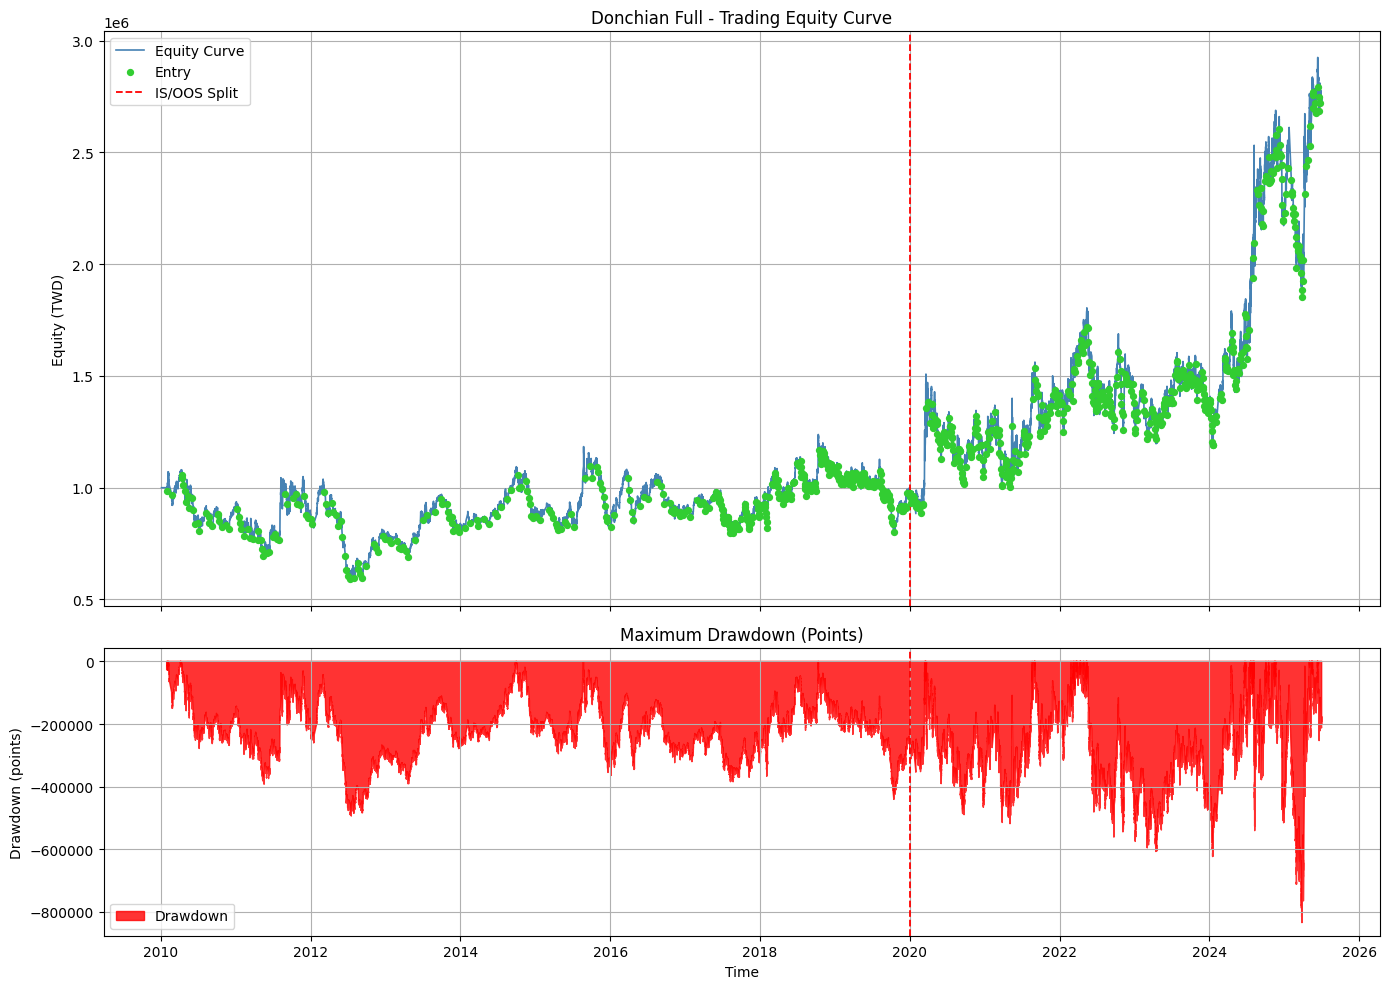

In [125]:
plot_equity_and_drawdown_colored(full_res_donchian,
                                 split_date="2020-01-01",
                                 title_prefix="Donchian Full")